# Donor lapse risk (predictive classification)

## 1. Problem framing

**Business problem.** Lighthouse-style nonprofits depend on repeat giving. Development staff cannot call every donor each month. We want a **forward-looking risk score**: who is likely to have **no giving activity** in the **next 90 days**, so admins can prioritize stewardship and retention outreach.

**Who cares.** Development / admin leads and executive leadership care about **retention**, forecastable revenue, and efficient staff time.

**Why it matters.** Missing a lapsing donor (false negative) means lost relationship and revenue; over-contacting low-risk donors (false positive) wastes time and may annoy supporters.

**Predictive vs explanatory (textbook framing).** The textbook distinguishes **predictive** modeling (optimize out-of-sample decisions) from **explanatory** or causal modeling (quantify defensible causes). **This notebook is predictive only:** we estimate the probability of a **defined future outcome** (no donation in the next 90 days) from information available **before** a monthly cutoff. Later sections interpret **which features the model uses** for that prediction; that is **not** the same as proving why donors lapse in a causal sense.

**Success criteria (operations).** We prioritize metrics that reflect ranking and rare-event capture: **ROC-AUC**, **precision–recall** at a chosen threshold, and **confusion-matrix** tradeoffs for outreach capacity. We also report a simple **baseline** (recency rule) to show lift.

**Data:** synthetic Lighthouse CSVs in `lighthouse_csv_v7/` ([supporters.csv](lighthouse_csv_v7/supporters.csv), [donations.csv](lighthouse_csv_v7/donations.csv)); optional joins documented below.

## 2. Data acquisition, preparation & exploration

We load supporter master records and donation events, validate keys and date types, then build a **monthly panel**: one row per `(supporter_id, cutoff)` where the supporter has **at least one donation strictly before** `cutoff` (known donors only).

**Label (target).** `target_lapse = 1` if there is **no** donation of **any** `donation_type` with `donation_date` in **(cutoff, cutoff + 90 days]**; `0` if at least one such donation occurs. Features use **only** donations with `donation_date < cutoff`.

**Right censoring.** Rows are dropped for cutoffs where the 90-day outcome window would extend **beyond** the latest observed `donation_date` in the extract (no reliable label).

**Reproducibility.** Paths are relative to this folder (`ml-pipelines/`). `random_state` is fixed where relevant.

In [2]:
import json
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

import importlib
import function as fn

importlib.reload(fn)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.inspection import permutation_importance

DATA = Path("lighthouse_csv_v7")
assert DATA.is_dir(), "Run notebook from ml-pipelines/ so lighthouse_csv_v7/ is visible."

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Paths OK:", DATA.resolve())

Paths OK: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/lighthouse_csv_v7


In [3]:
from db_config import engine, USE_DB, text

TRUTHY = {'1', 'true', 'yes', 't', 'y'}
FALSY  = {'0', 'false', 'no', 'f', 'n'}
BOOL_STRINGS = TRUTHY | FALSY

def load_table(table_name: str, csv_filename: str, parse_dates=None, **kwargs):
    """Load a table from Azure SQL when USE_DB=True, otherwise fall back to CSV."""
    import pandas as pd, os
    if USE_DB:
        df = pd.read_sql_table(table_name, engine)
        date_set = set(parse_dates or [])
        for col in date_set:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors='coerce')
        for col in df.select_dtypes(include='object').columns:
            if col in date_set:
                continue
            non_null = df[col].notna().sum()
            if non_null == 0:
                continue
            # Try numeric first (handles '0'/'1', DECIMAL values like '717.18')
            converted = pd.to_numeric(df[col], errors='coerce')
            if converted.notna().sum() == non_null:
                df[col] = converted
                continue
            # Try boolean-string coercion ('Yes'/'No', 'True'/'False', '0'/'1')
            unique_lower = {str(v).lower() for v in df[col].dropna().unique()}
            if unique_lower <= BOOL_STRINGS:
                df[col] = df[col].map(
                    lambda x: 1 if str(x).lower() in TRUTHY else (0 if pd.notna(x) else pd.NA)
                ).astype('Int64')
        return df
    else:
        csv_path = os.path.join('lighthouse_csv_v7', csv_filename)
        return pd.read_csv(csv_path, parse_dates=parse_dates or [], **kwargs)


⚠ No DB connection found — falling back to local CSV files
  Set DB_CONNECTION_STRING env var, or add the connection string to
  backend/Intex2.API/Intex2.API/appsettings.Development.json


In [4]:
supporters = load_table("supporters", "supporters.csv",
    parse_dates=["created_at", "first_donation_date"])
donations  = load_table("donations", "donations.csv",
    parse_dates=["donation_date"])
alloc      = load_table("donation_allocations", "donation_allocations.csv",
    parse_dates=["allocation_date"])

print("supporters:", supporters.shape)
print("donations:", donations.shape,
      "| date range:", donations["donation_date"].min().date(),
      "→", donations["donation_date"].max().date())
print("allocations:", alloc.shape)

supporters: (60, 15)
donations: (420, 13) | date range: 2023-01-09 → 2026-03-01
allocations: (521, 7)


In [5]:
# --- Monthly cutoffs & labels (no feature leakage) ---
data_end = donations["donation_date"].max()
last_valid_cutoff = data_end - pd.Timedelta(days=90)
first_cutoff = pd.Timestamp(donations["donation_date"].min()).replace(day=1) + pd.DateOffset(months=1)
cutoffs = pd.date_range(first_cutoff, last_valid_cutoff, freq="MS")
print(f"Cutoffs: {len(cutoffs)} | {cutoffs[0].date()} → {cutoffs[-1].date()}")
print("Label window: (cutoff, cutoff + 90 days]")

spine_rows = []
for cutoff in cutoffs:
    window_end = cutoff + pd.Timedelta(days=90)
    for sid in supporters["supporter_id"].values:
        prior_mask = (donations["supporter_id"] == sid) & (donations["donation_date"] < cutoff)
        if not prior_mask.any():
            continue
        fut_mask = (
            (donations["supporter_id"] == sid)
            & (donations["donation_date"] > cutoff)
            & (donations["donation_date"] <= window_end)
        )
        target_lapse = int(not fut_mask.any())
        spine_rows.append({"supporter_id": sid, "cutoff": cutoff, "target_lapse": target_lapse})

panel = pd.DataFrame(spine_rows)
print(panel.shape, "| lapse rate:", panel["target_lapse"].mean().round(3))
panel.head()

Cutoffs: 35 | 2023-02-01 → 2025-12-01
Label window: (cutoff, cutoff + 90 days]
(1695, 3) | lapse rate: 0.582


,supporter_id,cutoff,target_lapse
0,7,2023-02-01,1
1,19,2023-02-01,0
2,27,2023-02-01,1
3,32,2023-02-01,0
4,36,2023-02-01,0


In [6]:
# --- Feature engineering: RFM + statics + optional allocation breadth (all pre-cutoff) ---
don_alloc = donations.merge(
    alloc[["donation_id", "safehouse_id"]].drop_duplicates(),
    on="donation_id",
    how="left",
)
sup_cols = [
    "supporter_id",
    "supporter_type",
    "relationship_type",
    "region",
    "country",
    "acquisition_channel",
    "first_donation_date",
]
sup_small = supporters[sup_cols].copy()


def row_features(row: pd.Series) -> dict:
    sid, cutoff = int(row["supporter_id"]), pd.Timestamp(row["cutoff"])
    past = donations.loc[
        (donations["supporter_id"] == sid) & (donations["donation_date"] < cutoff)
    ].sort_values("donation_date")
    if past.empty:
        return None

    last_dt = past["donation_date"].max()
    first_dt = past["donation_date"].min()
    recency_days = (cutoff - last_dt).days
    tenure_don_days = (cutoff - first_dt).days

    def win(days):
        start = cutoff - pd.Timedelta(days=days)
        return past[past["donation_date"] >= start]

    w90, w180, w365 = win(90), win(180), win(365)
    amt = past["amount"].fillna(0) + past["estimated_value"].fillna(0)
    past_amt = past.assign(_gift=amt)

    def sum_gift(sub):
        if sub.empty:
            return 0.0
        return float(sub["amount"].fillna(0).sum() + sub["estimated_value"].fillna(0).sum())

    gifts_365 = past_amt[past_amt["donation_date"] >= cutoff - pd.Timedelta(days=365)]
    gift_sizes = gifts_365["amount"].fillna(0) + gifts_365["estimated_value"].fillna(0)
    avg_gift_365 = float(gift_sizes.mean()) if len(gift_sizes) else 0.0
    std_gift_365 = float(gift_sizes.std()) if len(gift_sizes) > 1 else 0.0

    # Inter-arrival (median gap) in prior 365d
    gdates = gifts_365["donation_date"].sort_values().values
    if len(gdates) >= 2:
        gaps = np.diff(gdates).astype("timedelta64[D]").astype(int)
        median_gap_days = float(np.median(gaps))
    else:
        median_gap_days = np.nan

    # Allocation / safehouse breadth in prior 365d (optional join)
    da = don_alloc.loc[
        (don_alloc["supporter_id"] == sid)
        & (don_alloc["donation_date"] < cutoff)
        & (don_alloc["donation_date"] >= cutoff - pd.Timedelta(days=365))
    ]
    n_distinct_safehouses_365 = da["safehouse_id"].nunique(dropna=True)

    srow = sup_small.loc[sup_small["supporter_id"] == sid].iloc[0]
    tenure_sup_days = (cutoff - pd.Timestamp(srow["first_donation_date"])).days

    out = {
        "recency_days": recency_days,
        "tenure_don_days": tenure_don_days,
        "tenure_sup_days": tenure_sup_days,
        "count_90d": len(w90),
        "count_180d": len(w180),
        "count_365d": len(w365),
        "sum_gift_365d": sum_gift(w365),
        "avg_gift_365d": avg_gift_365,
        "std_gift_365d": std_gift_365,
        "median_gap_days_365d": median_gap_days,
        "n_types_365d": gifts_365["donation_type"].nunique(),
        "recurring_rate_365d": gifts_365["is_recurring"].astype(float).mean(),
        "n_channels_365d": gifts_365["channel_source"].nunique(dropna=True),
        "n_campaigns_365d": gifts_365["campaign_name"].fillna("").nunique(),
        "n_distinct_safehouses_365d": n_distinct_safehouses_365,
        "cutoff_month": cutoff.month,
        "cutoff_year": cutoff.year,
        "supporter_type": srow["supporter_type"],
        "relationship_type": srow["relationship_type"],
        "region": srow["region"],
        "country": srow["country"],
        "acquisition_channel": srow["acquisition_channel"],
    }
    return out


feat_list = []
for _, r in panel.iterrows():
    d = row_features(r)
    if d is None:
        continue
    d["supporter_id"] = r["supporter_id"]
    d["cutoff"] = r["cutoff"]
    d["target_lapse"] = r["target_lapse"]
    feat_list.append(d)

df = pd.DataFrame(feat_list)
print(df.shape)
df.head()

(1695, 25)


,recency_days,tenure_don_days,tenure_sup_days,count_90d,count_180d,count_365d,sum_gift_365d,avg_gift_365d,std_gift_365d,median_gap_days_365d,...,cutoff_month,cutoff_year,supporter_type,relationship_type,region,country,acquisition_channel,supporter_id,cutoff,target_lapse
0,5,5,-260,1,1,1,9.67,9.67,0.0,NaN,...,2,2023,MonetaryDonor,International,Mindanao,USA,Event,7,2023-02-01,1
1,19,19,-670,1,1,1,699.32,699.32,0.0,NaN,...,2,2023,Volunteer,Local,Luzon,Philippines,SocialMedia,19,2023-02-01,0
2,16,16,-549,1,1,1,5.45,5.45,0.0,NaN,...,2,2023,MonetaryDonor,Local,Visayas,Philippines,WordOfMouth,27,2023-02-01,1
3,10,10,-1,1,1,1,677.82,677.82,0.0,NaN,...,2,2023,InKindDonor,Local,Luzon,Philippines,Event,32,2023-02-01,0
4,17,17,-74,1,1,1,1382.70,1382.70,0.0,NaN,...,2,2023,SocialMediaAdvocate,PartnerOrganization,Mindanao,Philippines,WordOfMouth,36,2023-02-01,0


In [7]:
# Missingness on modeling frame (Ch. 7)
_miss = df.drop(columns=["supporter_id", "cutoff"]).copy()
_clean, miss_report = fn.handle_missing_data(_miss, col_threshold=0.5, row_threshold=0.6)
print("Dropped columns (sparse):", miss_report.get("dropped_columns"))
print("Dropped rows (sparse):", miss_report.get("dropped_rows"))
ms = miss_report.get("missing_summary", pd.DataFrame())
if len(ms):
    display(ms.sort_values("missing_pct", ascending=False).head(15))

Dropped columns (sparse): []
Dropped rows (sparse): 0


,missing_count,missing_pct
median_gap_days_365d,679,0.400590
recurring_rate_365d,130,0.076696
n_channels_365d,0,0.000000
acquisition_channel,0,0.000000
country,0,0.000000
region,0,0.000000
relationship_type,0,0.000000
supporter_type,0,0.000000
cutoff_year,0,0.000000
cutoff_month,0,0.000000


### Exploration (Ch. 6–8)

We summarize univariate distributions for the **modeling frame** (`df`). We avoid tuning choices on the **final temporal test** months; exploratory plots inform preprocessing and feature selection narratives.

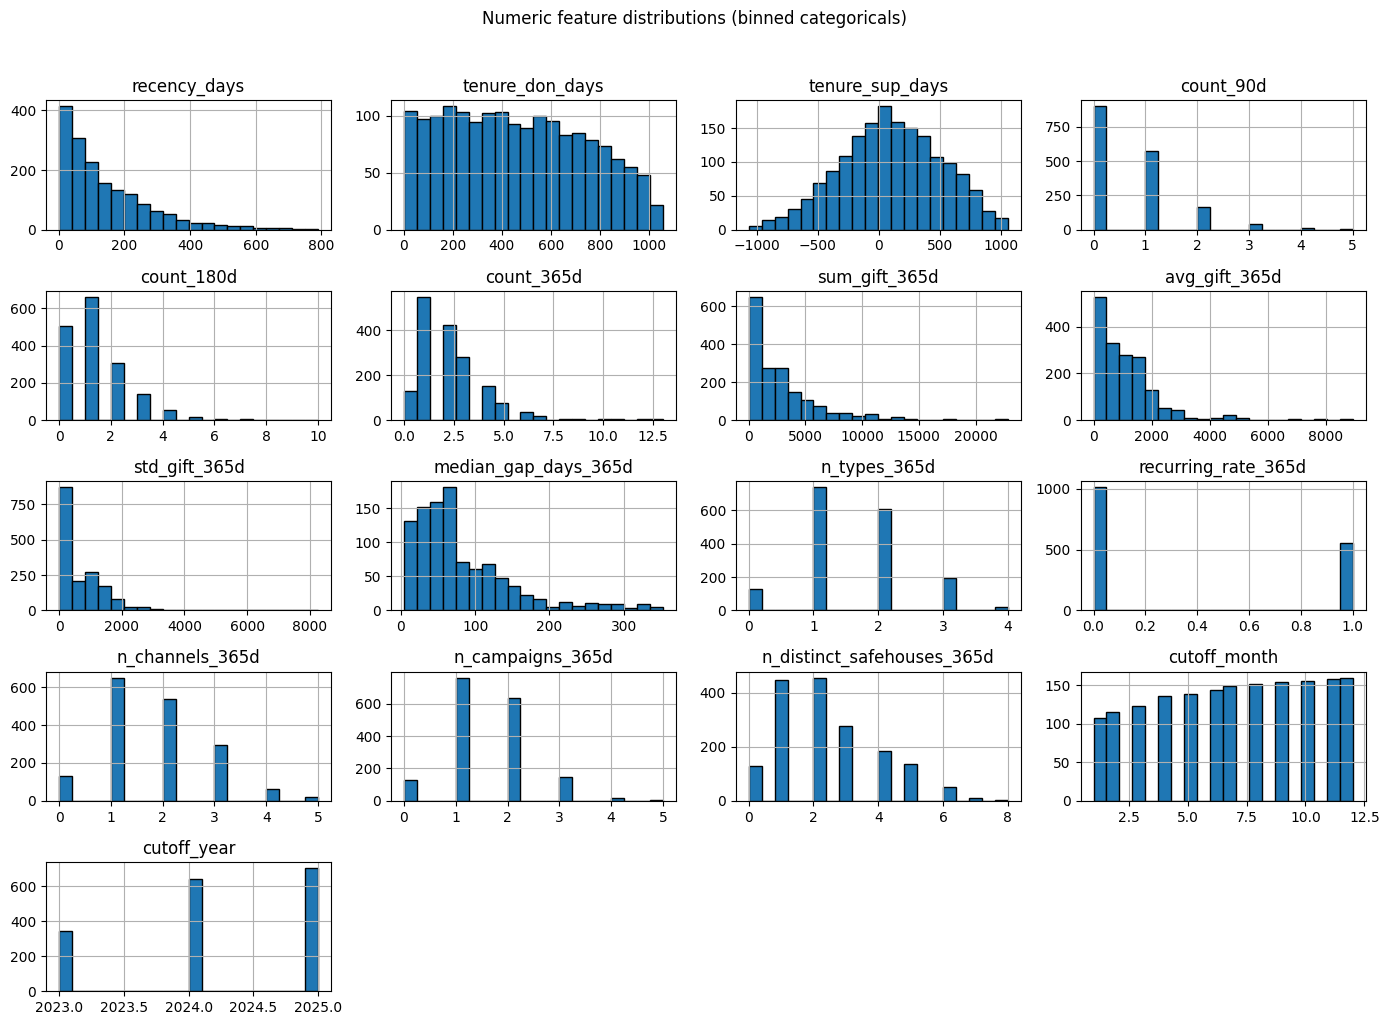

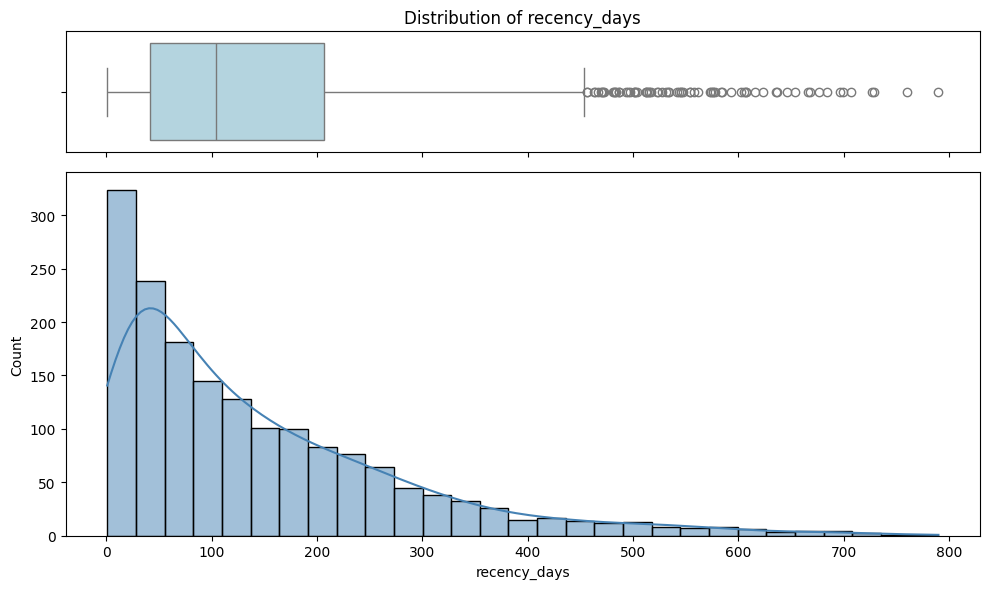

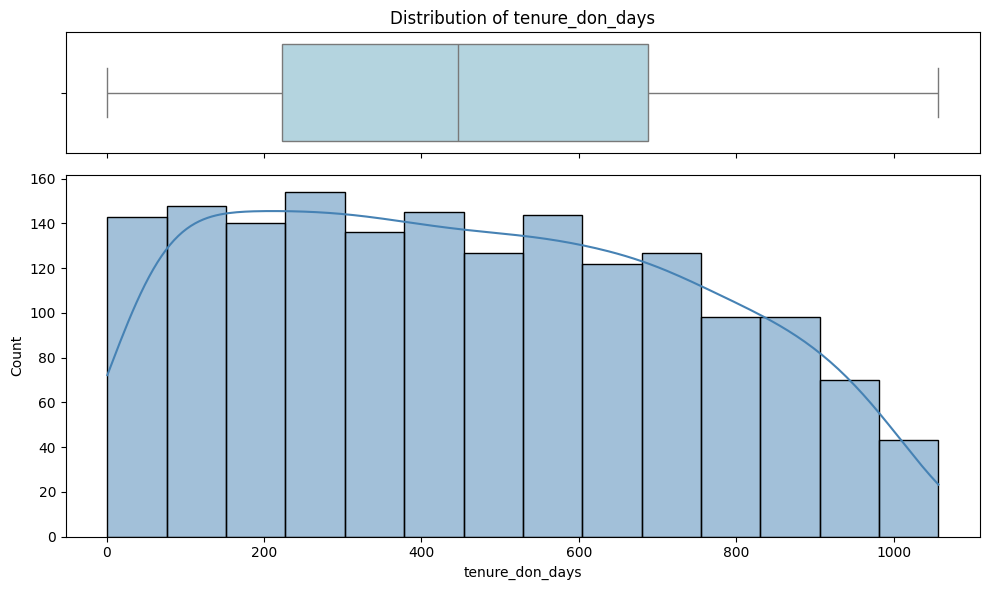

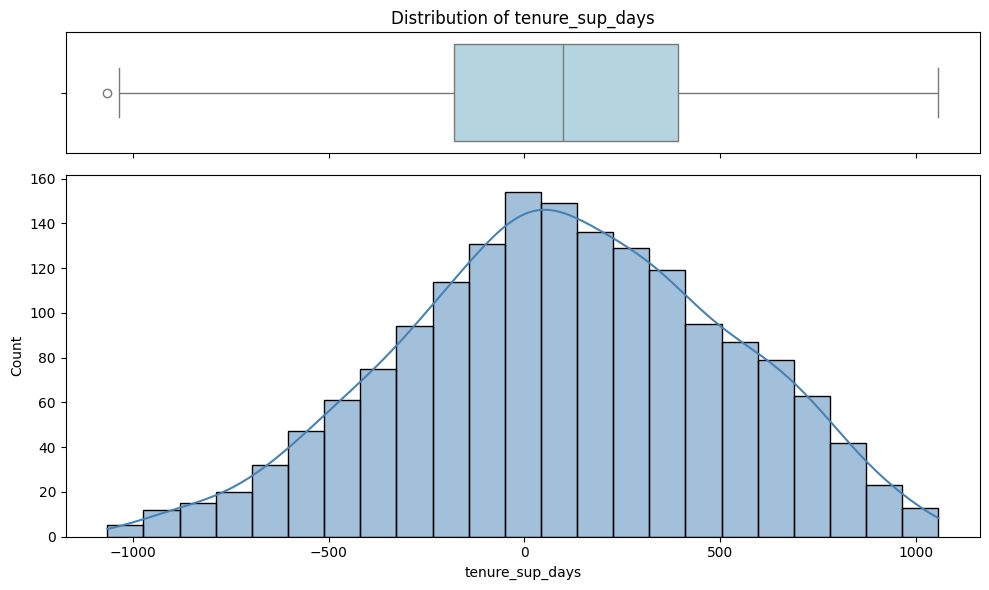

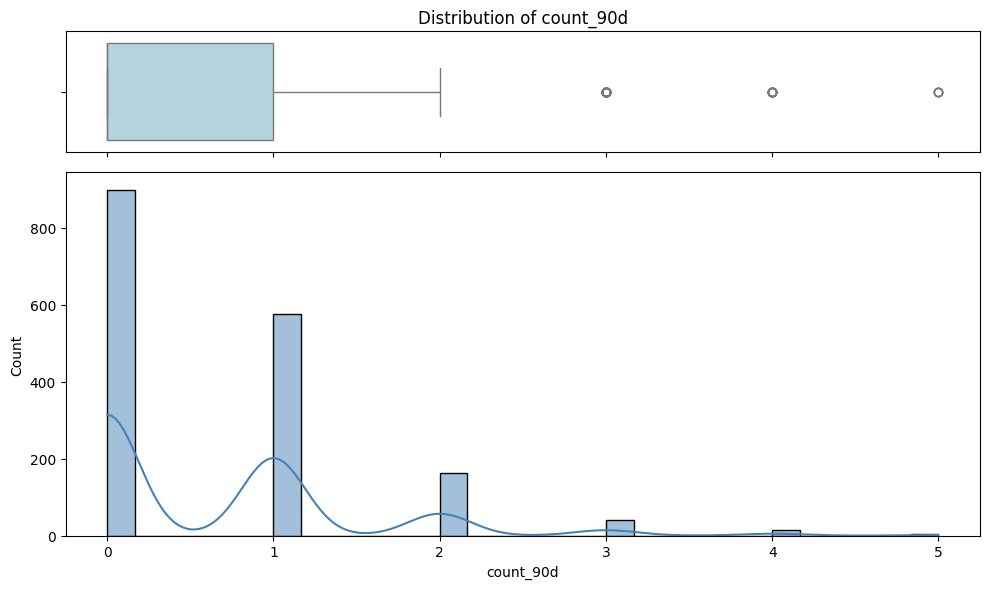

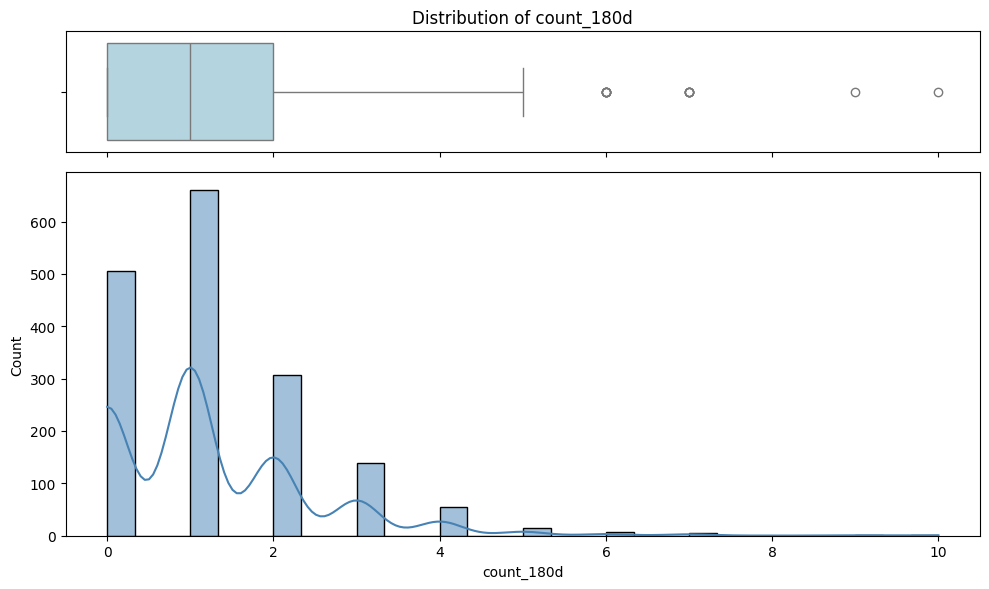

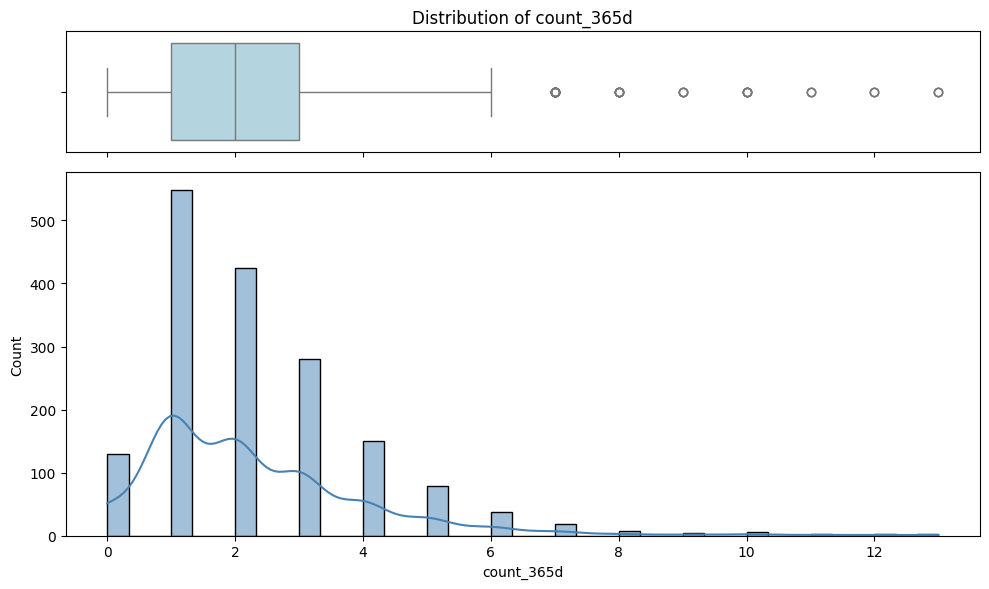

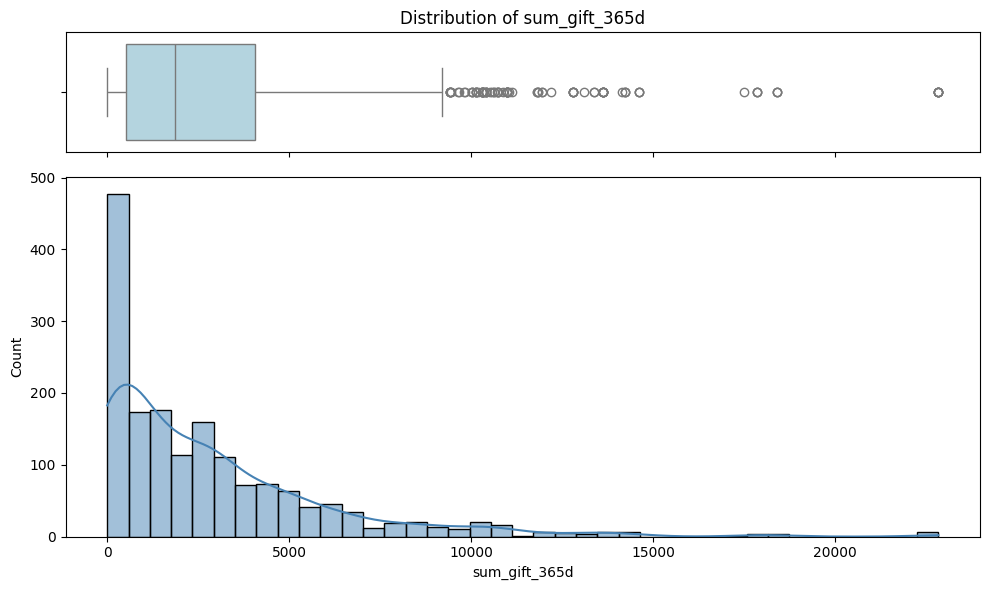

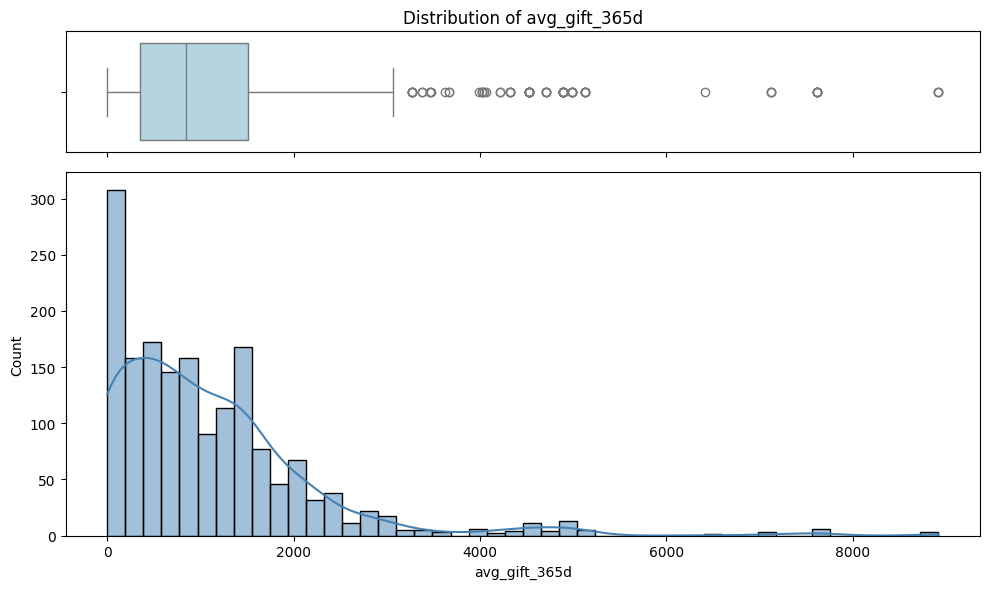

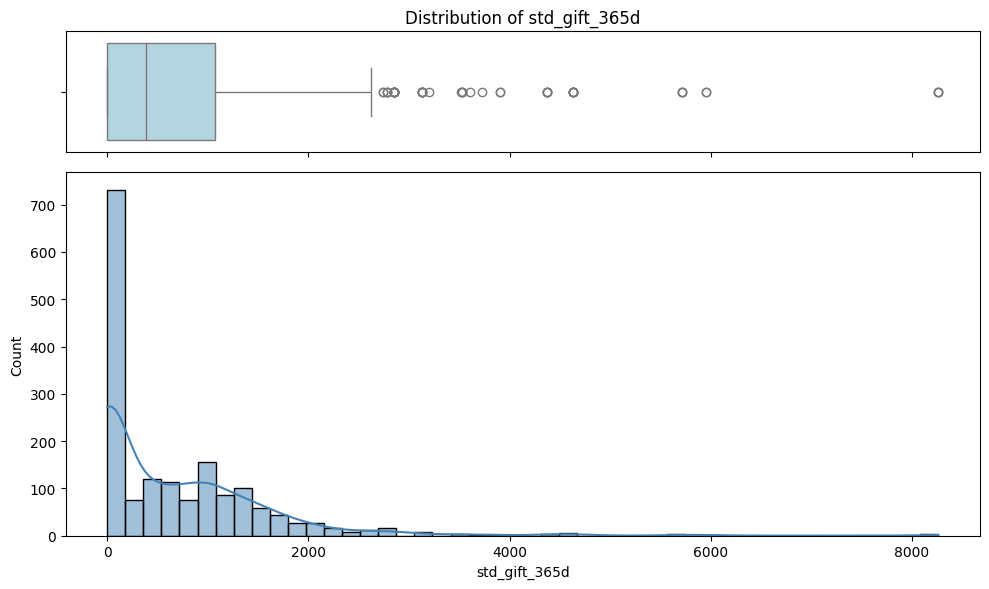

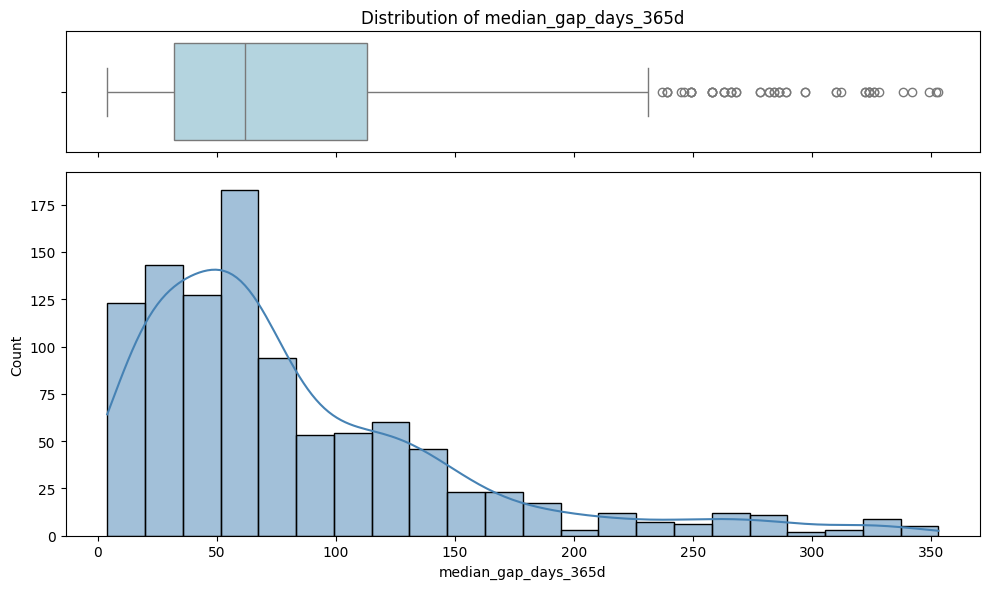

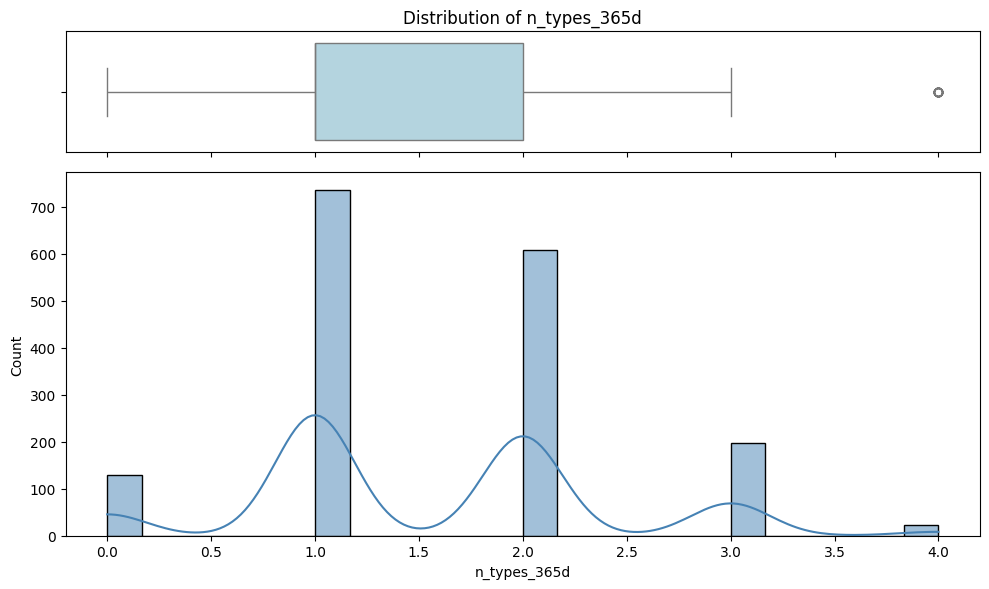

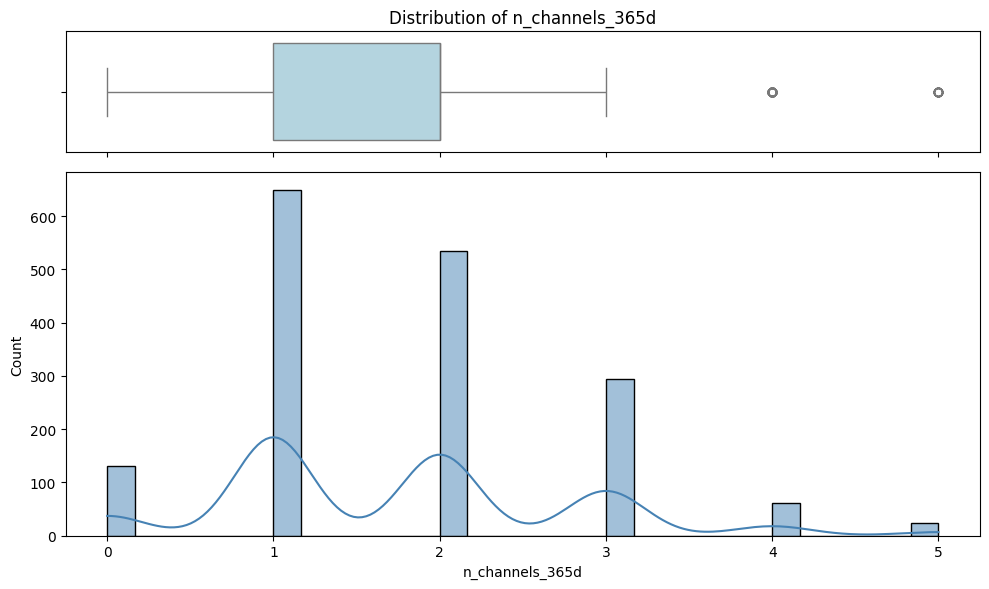

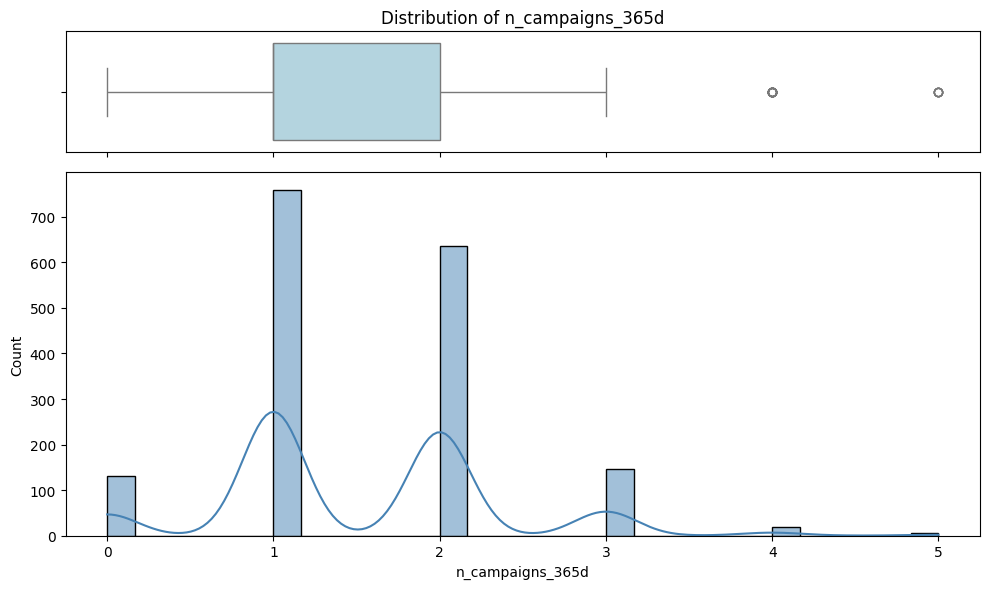

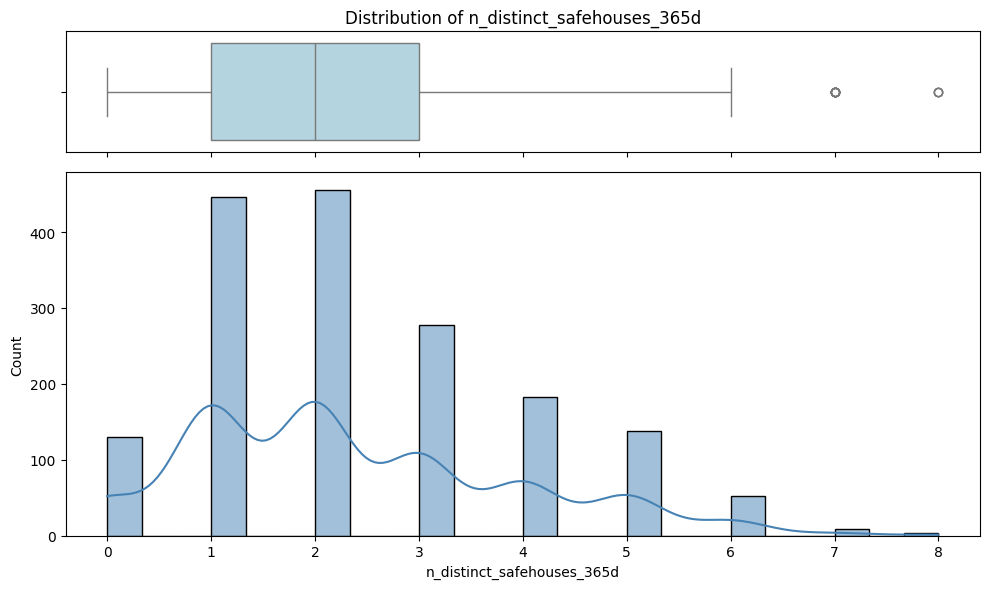

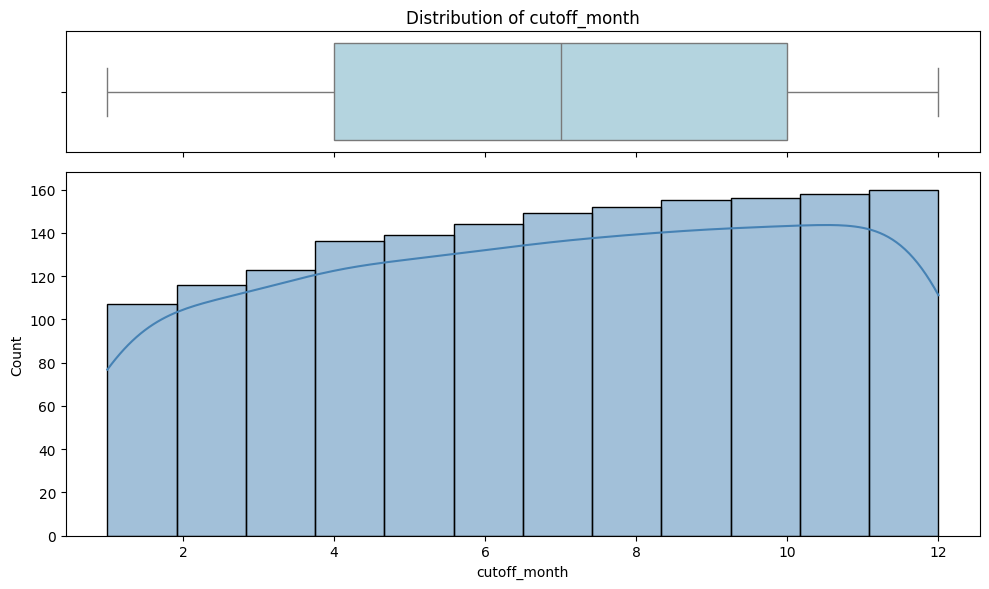

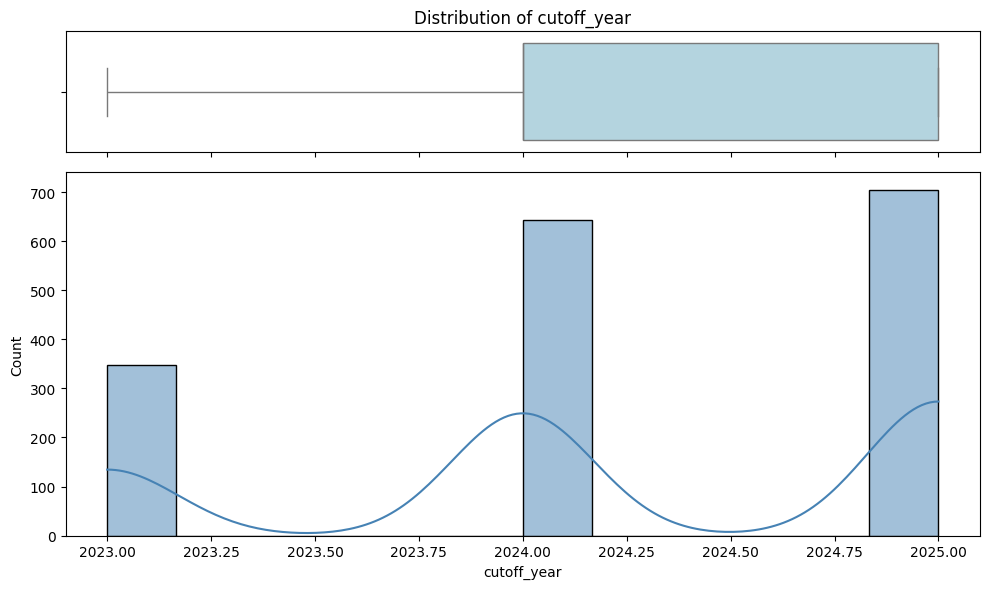

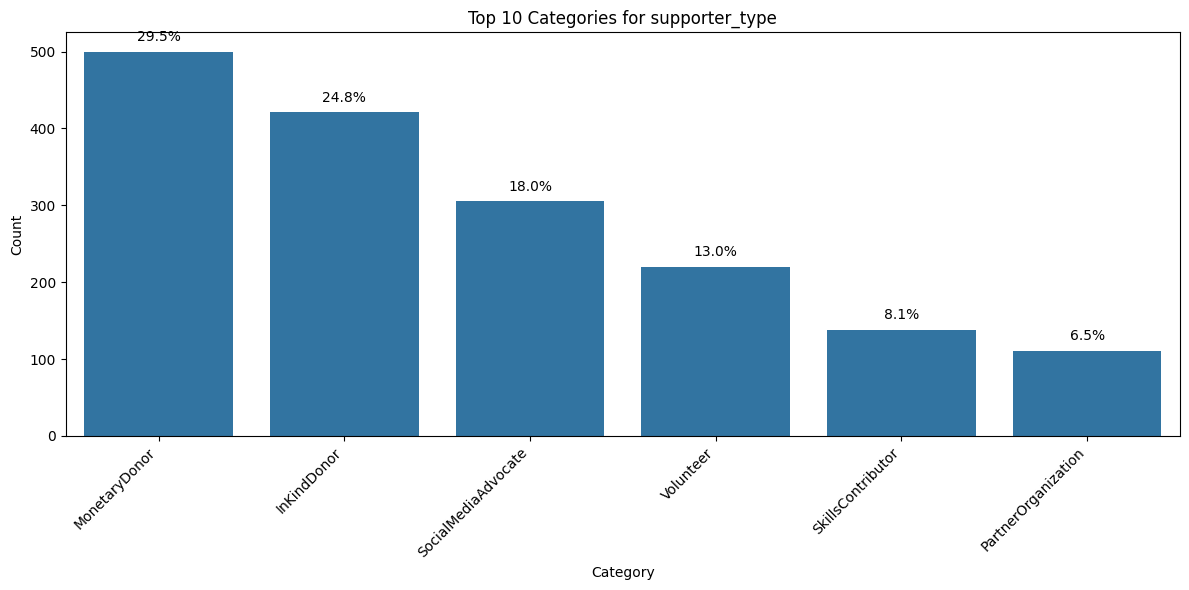

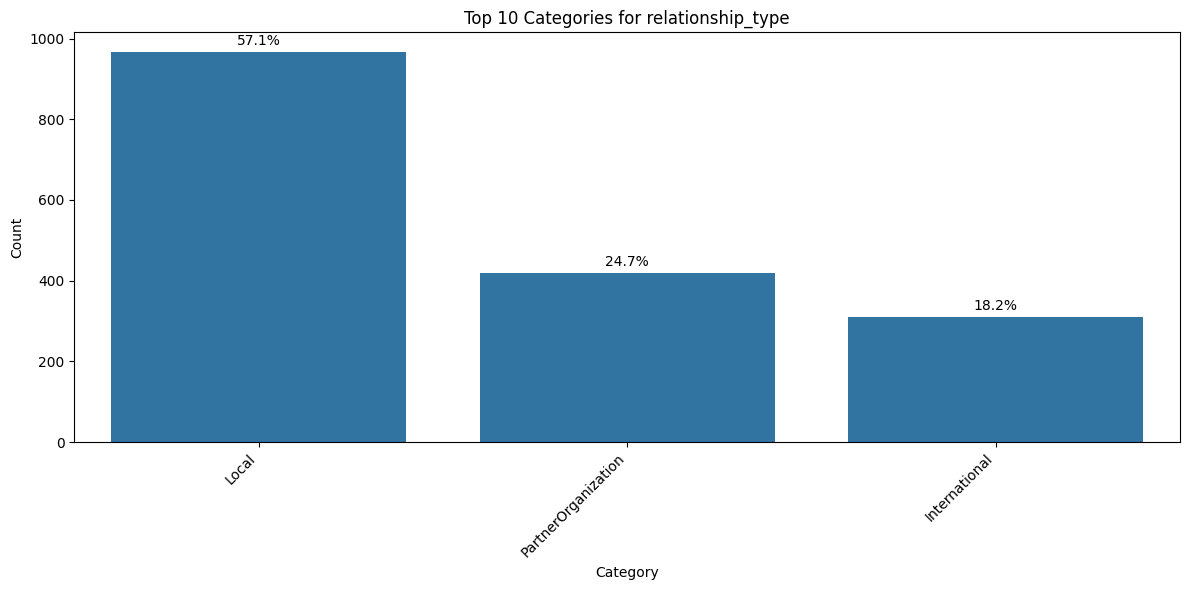

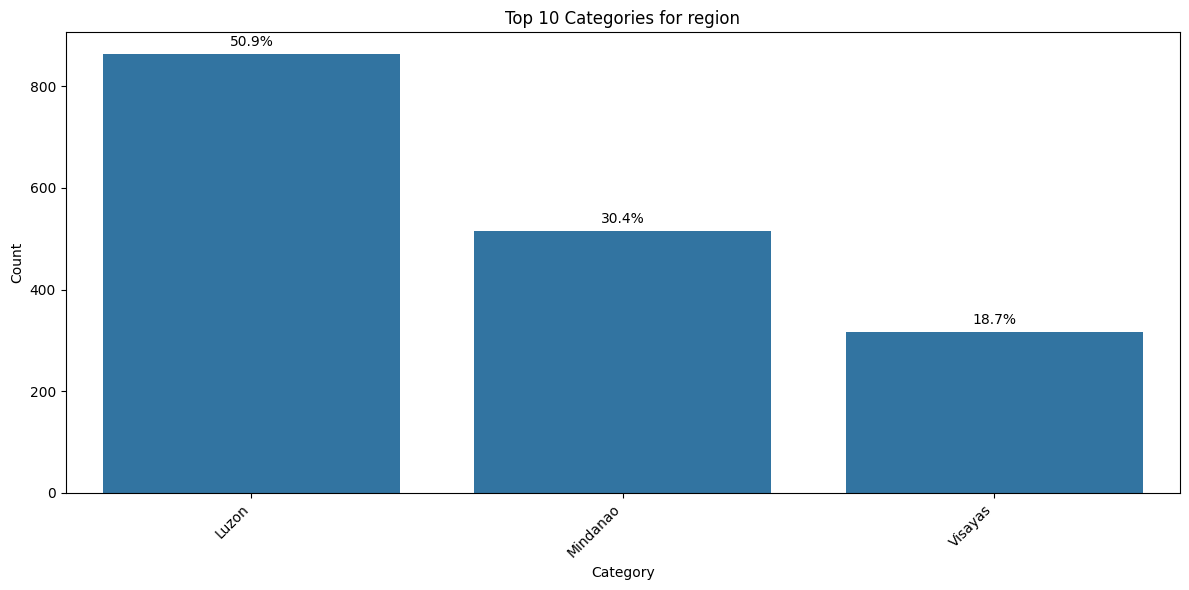

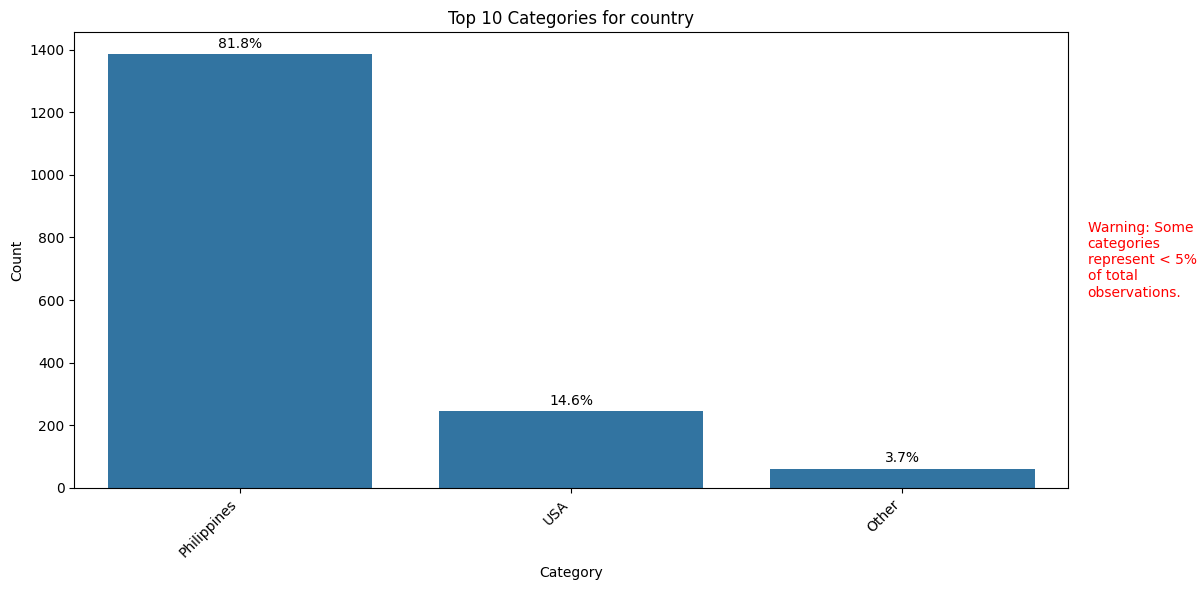

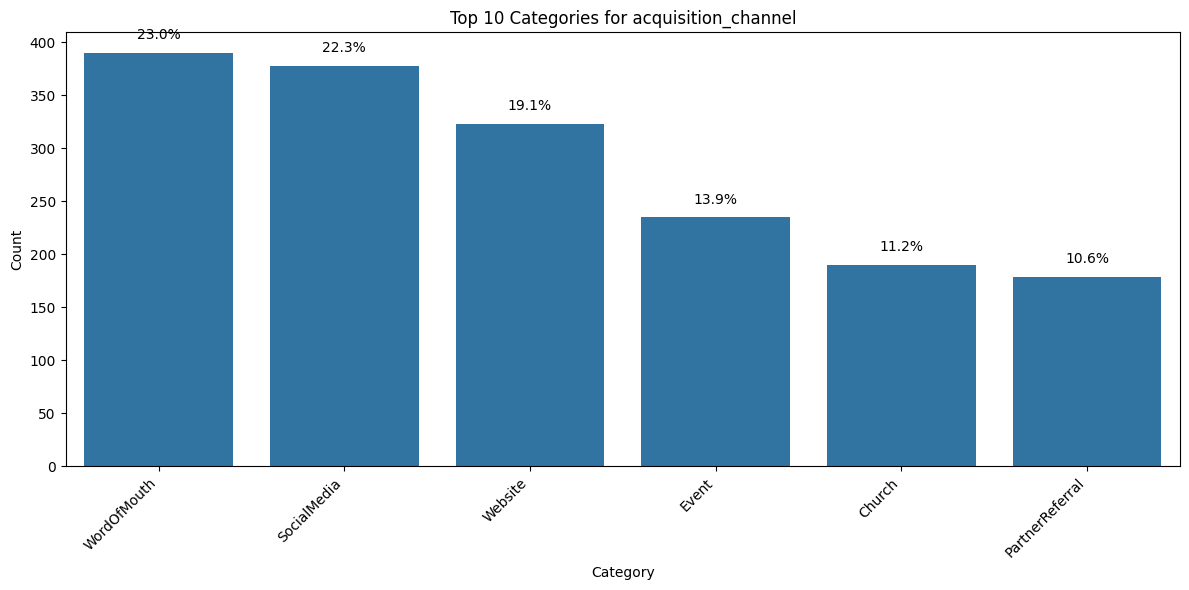

,Data Type,Count,Missing,Unique,Mode,Min,Q1,Median,Q3,Max,Mean,Std,Skew,Kurt
acquisition_channel,object,1695,0,6,WordOfMouth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_gift_365d,float64,1695,0,487,0.0,0.0,350.19,850.83,1507.535,8921.11,1096.419897,1127.85688,2.502099,10.116273
count_180d,int64,1695,0,10,1,0,0.0,1.0,2.0,10,1.223599,1.212454,1.568957,4.456571
count_365d,int64,1695,0,14,1,0,1.0,2.0,3.0,13,2.271386,1.776663,1.849813,5.833694
count_90d,int64,1695,0,6,0,0,0.0,0.0,1.0,5,0.646608,0.841415,1.550991,3.074076
country,object,1695,0,3,Philippines,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cutoff_month,int64,1695,0,12,12,1,4.0,7.0,10.0,12,6.892625,3.377862,-0.12985,-1.154249
cutoff_year,int64,1695,0,3,2025,2023,2024.0,2024.0,2025.0,2025,2024.211209,0.759197,-0.373634,-1.184635
median_gap_days_365d,float64,1016,679,208,15.0,4.0,32.0,62.0,113.0,353.0,81.627953,67.722226,1.641291,2.776403
n_campaigns_365d,int64,1695,0,6,1,0,1.0,1.0,2.0,5,1.515044,0.822272,0.516297,0.768467


In [8]:
eda_df = df.drop(columns=["supporter_id", "cutoff"]).copy()
# Rare level collapse for categoricals (Ch. 7 style)
for c in ["supporter_type", "relationship_type", "region", "country", "acquisition_channel"]:
    if c in eda_df.columns:
        vc = eda_df[c].value_counts(normalize=True)
        rare = vc[vc < 0.05].index
        eda_df.loc[eda_df[c].isin(rare), c] = "Other"

num_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()
if "target_lapse" in num_cols:
    num_cols.remove("target_lapse")

eda_df[num_cols].hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Numeric feature distributions (binned categoricals)", y=1.02)
plt.tight_layout()
plt.show()

uni = fn.univariate(eda_df.drop(columns=["target_lapse"], errors="ignore"))
display(uni.sort_index())

Mean values by target_lapse (0 = gives in window, 1 = lapse)


target_lapse,0,1
sum_gift_365d,3215.412698,2565.424853
cutoff_year,2024.165254,2024.244174
avg_gift_365d,1182.635126,1034.575539
std_gift_365d,708.541470,650.690321
tenure_don_days,476.612994,450.109422
recency_days,135.634181,150.570415
tenure_sup_days,110.491525,90.497467
median_gap_days_365d,80.594655,82.446208
cutoff_month,7.409605,6.521783
count_365d,2.557910,2.065856


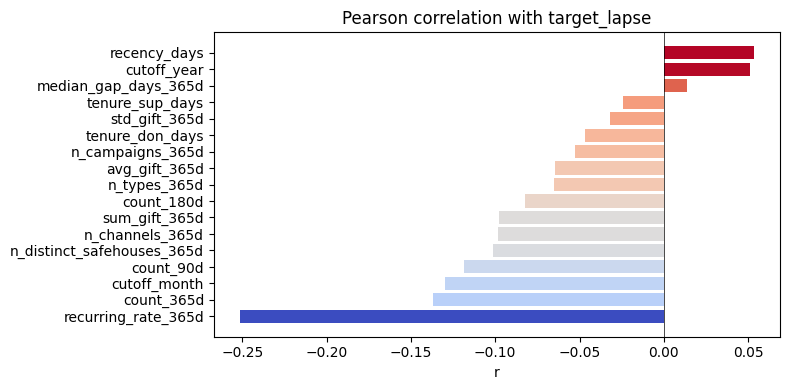

In [9]:
# Bivariate: mean numeric features by label
summ = (
    eda_df.groupby("target_lapse")[num_cols].mean().T.sort_values(by=0, ascending=False)
)
print("Mean values by target_lapse (0 = gives in window, 1 = lapse)")
display(summ)

corr = eda_df[num_cols + ["target_lapse"]].corr(numeric_only=True)["target_lapse"].drop("target_lapse").sort_values()
plt.figure(figsize=(8, max(4, len(corr) * 0.2)))
colors = plt.cm.coolwarm((corr.values - corr.values.min()) / (corr.values.max() - corr.values.min() + 1e-9))
for i, (v, idx) in enumerate(zip(corr.values, corr.index)):
    plt.barh(idx, v, color=colors[i])
plt.axvline(0, color="k", lw=0.5)
plt.title("Pearson correlation with target_lapse")
plt.xlabel("r")
plt.tight_layout()
plt.show()

## 3. Modeling & feature selection

**Temporal validation.** We hold out all panel rows with `cutoff >= 2025-06-01` for final evaluation; earlier months are used to fit and tune models. This approximates deploying the model after a fixed training history.

**Feature selection (Ch. 16, predictive lens).** We (1) exclude identifiers and timestamps used only for splitting (`supporter_id`, `cutoff`); (2) collapse rare categorical levels with `function.bin_categories` to stabilize one-hot encoding; (3) **clip** `recency_days` at the training **99th percentile** to limit outlier leverage (documented in Ch. 7 outlier discussion); (4) optionally drop one feature from a numeric pair with **|r| > 0.95** on the **training** frame only to reduce redundancy.

**Algorithms.** We compare **logistic regression**, **random forest**, **histogram gradient boosting** (`HistGradientBoostingClassifier`, fast native boosting in sklearn), and **classic gradient boosting** (`GradientBoostingClassifier`). If **`xgboost`** is installed, we add **`XGBClassifier`** as well (optional dependency). **Hyperparameters** are tuned with `GridSearchCV` and `TimeSeriesSplit` on training data ordered by `cutoff` (rows from the same calendar month remain contiguous — not perfect purge of supporter overlap, but avoids random shuffles that leak future months into earlier folds).

**sklearn `Pipeline`.** All imputation, scaling, and one-hot encoding run **inside** the pipeline so each CV fold fits preprocessing only on training folds (Ch. 7 / Ch. 11).

In [10]:
from IPython.display import display
from sklearn.base import clone

model_df = df.copy()
cat_cols = [
    "supporter_type",
    "relationship_type",
    "region",
    "country",
    "acquisition_channel",
]
fn.bin_categories(model_df[cat_cols])

CUTOFF_TEST_START = pd.Timestamp("2025-06-01")
train_df = model_df[model_df["cutoff"] < CUTOFF_TEST_START].copy()
test_df = model_df[model_df["cutoff"] >= CUTOFF_TEST_START].copy()
print("train rows:", len(train_df), "| test rows:", len(test_df))

# Outlier handling: clip recency on train quantile, apply to test
r99 = train_df["recency_days"].quantile(0.99)
train_df["recency_days"] = train_df["recency_days"].clip(upper=r99)
test_df["recency_days"] = test_df["recency_days"].clip(upper=r99)
print("recency_days clipped at train 99th pct:", float(r99))

# Redundant numeric pairs (train only) — exclude IDs / keys
num_for_corr = train_df.drop(
    columns=["supporter_id", "cutoff", "target_lapse"] + cat_cols, errors="ignore"
).select_dtypes(include=[np.number])
# Do not treat supporter_id as a feature if still numeric elsewhere
cm = num_for_corr.corr().abs()
upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))
drop_numeric = set()
for col in upper.columns:
    hits = upper.index[upper[col] > 0.95].tolist()
    for h in hits:
        drop_numeric.add(h)
print("Dropped highly correlated (>0.95) numeric columns (train):", sorted(drop_numeric))

feature_numeric = [
    c
    for c in num_for_corr.columns
    if c not in drop_numeric
]

DROP_FROM_X = ["supporter_id", "cutoff"]
X_train = train_df.drop(columns=["target_lapse"] + DROP_FROM_X)
y_train = train_df["target_lapse"]
X_test = test_df.drop(columns=["target_lapse"] + DROP_FROM_X)
y_test = test_df["target_lapse"]

# Baseline: high recency → predict lapse
med_rec = train_df["recency_days"].median()
baseline_pred = (test_df["recency_days"] > med_rec).astype(int)
print("Baseline (recency > train median):", med_rec, "days")

numeric_features = [c for c in feature_numeric if c in X_train.columns]
categorical_features = [c for c in cat_cols if c in X_train.columns]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "oh",
                        OneHotEncoder(handle_unknown="ignore", max_categories=25),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

ordered = train_df.sort_values(["cutoff", "supporter_id"]).reset_index(drop=True)
X_ord = ordered.drop(columns=["target_lapse"] + DROP_FROM_X)
y_ord = ordered["target_lapse"]
tscv = TimeSeriesSplit(n_splits=4)

log_pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        (
            "clf",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

param_log = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
    "clf__solver": ["lbfgs", "saga"],
}

gs_log = GridSearchCV(
    log_pipe,
    param_log,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=1,
    refit=True,
)
gs_log.fit(X_ord, y_ord)
print("Best logistic:", gs_log.best_params_, "CV ROC-AUC:", round(gs_log.best_score_, 4))

rf_prep = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "oh",
                        OneHotEncoder(handle_unknown="ignore", max_categories=25),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

rf_pipe = Pipeline(
    steps=[
        ("prep", rf_prep),
        (
            "clf",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample",
                n_jobs=1,
            ),
        ),
    ]
)

param_rf = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 8, 12],
    "clf__min_samples_leaf": [1, 5],
}

gs_rf = GridSearchCV(
    rf_pipe,
    param_rf,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=1,
    refit=True,
)
gs_rf.fit(X_ord, y_ord)
print("Best RF:", gs_rf.best_params_, "CV ROC-AUC:", round(gs_rf.best_score_, 4))

# --- Boosting models (sklearn + optional XGBoost) ---
hgb_pipe = Pipeline(
    steps=[
        ("prep", clone(rf_prep)),
        (
            "clf",
            HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced",
            ),
        ),
    ]
)
param_hgb = {
    "clf__max_iter": [150, 300],
    "clf__max_depth": [None, 8, 12],
    "clf__learning_rate": [0.03, 0.1],
}
gs_hgb = GridSearchCV(
    hgb_pipe,
    param_hgb,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=1,
    refit=True,
)
gs_hgb.fit(X_ord, y_ord)
print(
    "Best HistGradientBoosting:",
    gs_hgb.best_params_,
    "CV ROC-AUC:",
    round(gs_hgb.best_score_, 4),
)

gbm_pipe = Pipeline(
    steps=[
        ("prep", clone(rf_prep)),
        (
            "clf",
            GradientBoostingClassifier(random_state=RANDOM_STATE),
        ),
    ]
)
param_gbm = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.05, 0.1],
}
gs_gbm = GridSearchCV(
    gbm_pipe,
    param_gbm,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=1,
    refit=True,
)
gs_gbm.fit(X_ord, y_ord)
print(
    "Best GradientBoosting:",
    gs_gbm.best_params_,
    "CV ROC-AUC:",
    round(gs_gbm.best_score_, 4),
)

models = {
    "logistic": gs_log.best_estimator_,
    "random_forest": gs_rf.best_estimator_,
    "hist_gradient_boosting": gs_hgb.best_estimator_,
    "gradient_boosting": gs_gbm.best_estimator_,
}

HAS_XGB = False
try:
    from xgboost import XGBClassifier

    pos = (y_ord == 1).sum()
    neg = (y_ord == 0).sum()
    spw = float(neg / max(pos, 1))
    xgb_pipe = Pipeline(
        steps=[
            ("prep", clone(rf_prep)),
            (
                "clf",
                XGBClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    scale_pos_weight=spw,
                    eval_metric="logloss",
                ),
            ),
        ]
    )
    param_xgb = {
        "clf__n_estimators": [150, 300],
        "clf__max_depth": [4, 8],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8, 1.0],
    }
    gs_xgb = GridSearchCV(
        xgb_pipe,
        param_xgb,
        cv=tscv,
        scoring="roc_auc",
        n_jobs=1,
        refit=True,
    )
    gs_xgb.fit(X_ord, y_ord)
    print(
        "Best XGBoost:",
        gs_xgb.best_params_,
        "CV ROC-AUC:",
        round(gs_xgb.best_score_, 4),
    )
    models["xgboost"] = gs_xgb.best_estimator_
    HAS_XGB = True
except ImportError:
    print("xgboost not installed; skipping XGBClassifier (pip install xgboost to include it).")

train rows: 1282 | test rows: 413
recency_days clipped at train 99th pct: 503.90000000000055
Dropped highly correlated (>0.95) numeric columns (train): []
Baseline (recency > train median): 93.0 days


/Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/function.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df[col].isin(less_than_5.index), col] = 'Other'
/Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/function.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df[col].isin(less_than_5.index), col] = 'Other'
/Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/function.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

Best logistic: {'clf__C': 0.01, 'clf__solver': 'saga'} CV ROC-AUC: 0.6893
Best RF: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400} CV ROC-AUC: 0.7131
Best HistGradientBoosting: {'clf__learning_rate': 0.1, 'clf__max_depth': None, 'clf__max_iter': 300} CV ROC-AUC: 0.7293
Best GradientBoosting: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100} CV ROC-AUC: 0.7172
Best XGBoost: {'clf__learning_rate': 0.1, 'clf__max_depth': 8, 'clf__n_estimators': 300, 'clf__subsample': 0.8} CV ROC-AUC: 0.7387


## 4. Evaluation & interpretation

We report **out-of-sample** performance on held-out **cutoff months** (not random rows). **ROC-AUC** summarizes ranking; **average precision (PR-AUC)** is informative if lapse prevalence is far from 50%. We show **precision–recall** at a default threshold of 0.5 and discuss **business tradeoffs** for moving that threshold.

**False negatives** (predict “will not lapse” but donor lapses): missed stewardship, lost revenue. **False positives** (predict lapse but donor would still give): wasted staff time and possible donor fatigue.

,model,roc_auc,avg_precision
4,xgboost,0.668254,0.689681
1,random_forest,0.655464,0.688634
2,hist_gradient_boosting,0.644995,0.667058
3,gradient_boosting,0.641999,0.665856
0,logistic,0.528705,0.575396


Chosen for downstream interpretation: xgboost
              precision    recall  f1-score   support

gives_in_90d       0.60      0.68      0.64       186
       lapse       0.70      0.62      0.66       227

    accuracy                           0.65       413
   macro avg       0.65      0.65      0.65       413
weighted avg       0.66      0.65      0.65       413



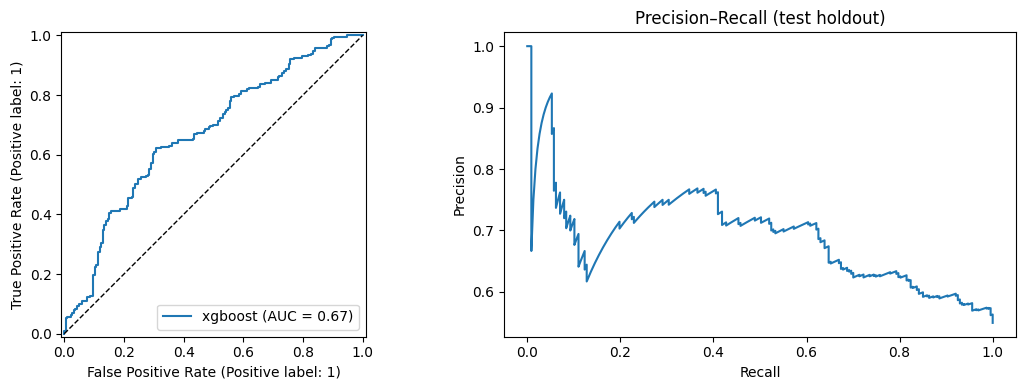

Confusion matrix [ [TN FP] [FN TP] ] at threshold 0.5:
 [[127  59]
 [ 86 141]]
Baseline accuracy: 0.5448
Baseline ROC-AUC: 0.5349


In [11]:
results = []
for name, est in models.items():
    proba = est.predict_proba(X_test)[:, 1]
    results.append(
        {
            "model": name,
            "roc_auc": roc_auc_score(y_test, proba),
            "avg_precision": average_precision_score(y_test, proba),
        }
    )

res_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(res_df)

best_name = res_df.iloc[0]["model"]
best_model = models[best_name]
y_score = best_model.predict_proba(X_test)[:, 1]
y_hat = (y_score >= 0.5).astype(int)

print("Chosen for downstream interpretation:", best_name)
print(classification_report(y_test, y_hat, target_names=["gives_in_90d", "lapse"]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, y_score, ax=ax[0], name=best_name)
ax[0].plot([0, 1], [0, 1], "k--", lw=1)
prec, rec, thr = precision_recall_curve(y_test, y_score)
ax[1].plot(rec, prec)
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision–Recall (test holdout)")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_hat)
print("Confusion matrix [ [TN FP] [FN TP] ] at threshold 0.5:\n", cm)

# Baseline metrics (recency rule)
print("Baseline accuracy:", round((baseline_pred == y_test).mean(), 4))
try:
    print("Baseline ROC-AUC:", round(roc_auc_score(y_test, baseline_pred), 4))
except ValueError:
    print("Baseline ROC-AUC: n/a (single-class predictions)")

## 5. Relationship analysis (predictive model — not causal inference)

This section satisfies the assignment’s request to discuss **relationships** in the data while keeping the project **predictive only**.

**What we show.** **Permutation importance** measures how much **test-set** score drops when a **raw input column** of `X` is shuffled (for a `Pipeline`, sklearn permutes columns **before** preprocessing—**one score per raw column**, not one per one-hot dummy). Large drops mean the model **relied** on that column for predictions in this sample. **§5b** optionally **drops raw features with negative permutation importance** and refits the winning model **only if** test ROC-AUC does not worsen.

**What we do *not* claim.** Higher importance does **not** mean “changing that factor causes donors to lapse.” Confounders (seasonality, unobserved life events, campaign calendars) can create **spurious** associations. **Correlation is not causation**; outreach priorities should use **probabilities from §4**, not “fix the top feature” logic.

**Stress test (critical evaluator).** (1) **Leakage:** we excluded post-cutoff gifts from features; using `supporters.status` could reintroduce subtle leakage if status is updated from future behavior—we omit it. (2) **Panel dependence:** the same donor appears across months; temporal holdout helps, but **GroupKFold by donor** would be stricter for hyperparameter tuning. (3) **Class balance:** lapse is common here (~58%); PR-AUC still matters if prevalence shifts in production. (4) **Right censoring:** labels for the last cutoffs require 90 days of future horizon inside the extract.

,feature,importance_mean,importance_std
2,tenure_sup_days,0.100152,0.016228
11,recurring_rate_365d,0.075708,0.013051
7,avg_gift_365d,0.017187,0.007044
21,acquisition_channel,0.014984,0.005702
17,supporter_type,0.014611,0.004568
0,recency_days,0.010503,0.011364
15,cutoff_month,0.009750,0.003881
19,region,0.007852,0.005649
18,relationship_type,0.004340,0.004315
6,sum_gift_365d,0.003929,0.004233


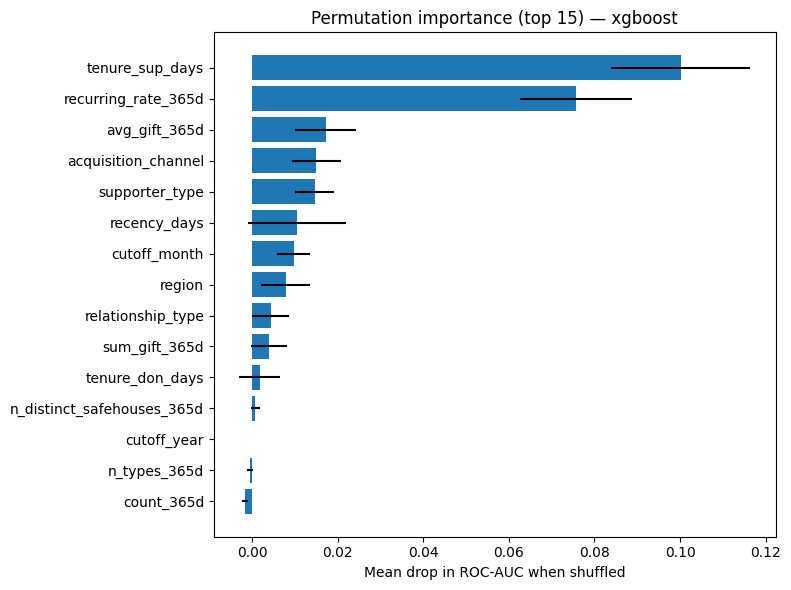

In [12]:
# Permutation importance on held-out rows (interpret predictive model, not causes)
sample_n = min(400, len(X_test))
X_perm = X_test.sample(sample_n, random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index]

perm = permutation_importance(
    best_model,
    X_perm,
    y_perm,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    n_jobs=1,
)

prep = best_model.named_steps["prep"]
# permutation_importance permutes *raw* columns of X (one score per input column).
# len matches X.shape[1], not len(prep.get_feature_names_out()) after OHE.
feat_names = np.asarray(X_perm.columns)
if len(feat_names) != len(perm.importances_mean):
    feat_names = np.array([f"f{i}" for i in range(len(perm.importances_mean))])

imp = pd.DataFrame(
    {"feature": feat_names, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std}
).sort_values("importance_mean", ascending=False)

display(imp.head(20))

plt.figure(figsize=(8, 6))
top = imp.head(15).iloc[::-1]
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.xlabel("Mean drop in ROC-AUC when shuffled")
plt.title(f"Permutation importance (top 15) — {best_name}")
plt.tight_layout()
plt.show()

### 5b. Prune features with negative permutation importance (optional refinement)

Textbook-style guidance: **columns whose shuffling does not hurt (or “helps”) ROC-AUC** add noise or hurt stability. Importances are aligned to **raw** `DataFrame` columns (same as sklearn’s permutation loop). If names were ever post-prep (`num__` / `cat__`), we **sum** one-hot pieces back onto each categorical. **Drop** numerics and categoricals with **importance &lt; 0**, then **refit only the winning model family**. **Negative values can be Monte Carlo noise**—we **keep the pruned model only if test ROC-AUC does not get worse**.

In [13]:
def aggregate_perm_to_raw(
    feat_names,
    imp_mean,
    numeric_features,
    categorical_features,
    *,
    raw_column_order=None,
):
    """Map permutation importances to raw numeric / categorical columns.

    sklearn's permutation_importance on a Pipeline uses *raw* X columns (one score per
    column). Names are then typically real column names from the DataFrame.

    Also supports post-prep names (num__ / cat__...) and f0,f1,... fallback indexed
    by raw_column_order (defaults to numeric_features + categorical_features).
    """
    num_imp = {c: 0.0 for c in numeric_features}
    cat_imp = {c: 0.0 for c in categorical_features}
    num_set = set(numeric_features)
    cat_set = set(categorical_features)

    for fname, im in zip(feat_names, imp_mean):
        s = str(fname)
        if s.startswith("num__"):
            col = s.split("__", 1)[1]
            if col in num_imp:
                num_imp[col] = float(im)
        elif s.startswith("cat__"):
            rest = s.split("__", 1)[1]
            for c in sorted(categorical_features, key=len, reverse=True):
                if rest == c or rest.startswith(c + "_"):
                    cat_imp[c] += float(im)
                    break
        elif s in num_set:
            num_imp[s] += float(im)
        elif s in cat_set:
            cat_imp[s] += float(im)
        elif len(s) >= 2 and s[0] == "f" and s[1:].isdigit():
            order = raw_column_order
            if order is None:
                order = list(numeric_features) + list(categorical_features)
            idx = int(s[1:])
            if 0 <= idx < len(order):
                col = order[idx]
                if col in num_set:
                    num_imp[col] += float(im)
                elif col in cat_set:
                    cat_imp[col] += float(im)
    return num_imp, cat_imp


num_imp_agg, cat_imp_agg = aggregate_perm_to_raw(
    feat_names,
    perm.importances_mean,
    numeric_features,
    categorical_features,
    raw_column_order=list(X_perm.columns),
)

drop_neg_num = [c for c in numeric_features if num_imp_agg.get(c, 0.0) < 0]
drop_neg_cat = [c for c in categorical_features if cat_imp_agg.get(c, 0.0) < 0]
print("Drop numeric (negative PI):", drop_neg_num)
print("Drop categorical (negative summed PI):", drop_neg_cat)

num_p = [c for c in numeric_features if c not in drop_neg_num]
cat_p = [c for c in categorical_features if c not in drop_neg_cat]

if len(num_p) + len(cat_p) == 0:
    print("Pruning skipped: no features left.")
else:
    auc_before = float(roc_auc_score(y_test, y_score))
    feat_cols = num_p + cat_p
    X_ord_p = X_ord[feat_cols]
    X_test_p = X_test[feat_cols]

    preprocess_p = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_p,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "oh",
                            OneHotEncoder(handle_unknown="ignore", max_categories=25),
                        ),
                    ]
                ),
                cat_p,
            ),
        ]
    )
    rf_prep_p = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), num_p),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "oh",
                            OneHotEncoder(handle_unknown="ignore", max_categories=25),
                        ),
                    ]
                ),
                cat_p,
            ),
        ]
    )

    if best_name == "logistic":
        pipe_p = Pipeline(
            steps=[
                ("prep", preprocess_p),
                (
                    "clf",
                    LogisticRegression(
                        max_iter=3000,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )
        pipe_p.set_params(**gs_log.best_params_)
        pipe_p.fit(X_ord_p, y_ord)
        pruned_est = pipe_p
    elif best_name == "random_forest":
        pipe_p = Pipeline(
            steps=[
                ("prep", rf_prep_p),
                (
                    "clf",
                    RandomForestClassifier(
                        random_state=RANDOM_STATE,
                        class_weight="balanced_subsample",
                        n_jobs=1,
                    ),
                ),
            ]
        )
        pipe_p.set_params(**gs_rf.best_params_)
        pipe_p.fit(X_ord_p, y_ord)
        pruned_est = pipe_p
    elif best_name == "hist_gradient_boosting":
        pipe_p = Pipeline(
            steps=[
                ("prep", rf_prep_p),
                (
                    "clf",
                    HistGradientBoostingClassifier(
                        random_state=RANDOM_STATE,
                        class_weight="balanced",
                    ),
                ),
            ]
        )
        pipe_p.set_params(**gs_hgb.best_params_)
        pipe_p.fit(X_ord_p, y_ord)
        pruned_est = pipe_p
    elif best_name == "gradient_boosting":
        pipe_p = Pipeline(
            steps=[
                ("prep", rf_prep_p),
                (
                    "clf",
                    GradientBoostingClassifier(random_state=RANDOM_STATE),
                ),
            ]
        )
        pipe_p.set_params(**gs_gbm.best_params_)
        pipe_p.fit(X_ord_p, y_ord)
        pruned_est = pipe_p
    elif best_name == "xgboost" and HAS_XGB:
        from xgboost import XGBClassifier

        pos = (y_ord == 1).sum()
        neg = (y_ord == 0).sum()
        spw = float(neg / max(pos, 1))
        pipe_p = Pipeline(
            steps=[
                ("prep", rf_prep_p),
                (
                    "clf",
                    XGBClassifier(
                        random_state=RANDOM_STATE,
                        n_jobs=1,
                        scale_pos_weight=spw,
                        eval_metric="logloss",
                    ),
                ),
            ]
        )
        pipe_p.set_params(**gs_xgb.best_params_)
        pipe_p.fit(X_ord_p, y_ord)
        pruned_est = pipe_p
    else:
        pruned_est = None

    if pruned_est is not None:
        y_score_p = pruned_est.predict_proba(X_test_p)[:, 1]
        auc_after = float(roc_auc_score(y_test, y_score_p))
        print(f"Test ROC-AUC before prune: {auc_before:.4f} | after prune: {auc_after:.4f}")
        if auc_after >= auc_before:
            best_model = pruned_est
            y_score = y_score_p
            numeric_features = num_p
            categorical_features = cat_p
            X_test = X_test_p
            models[best_name] = best_model
            row = res_df["model"] == best_name
            res_df.loc[row, "roc_auc"] = auc_after
            res_df.loc[row, "avg_precision"] = average_precision_score(y_test, y_score_p)
            print("Adopted pruned feature set and refitted model.")
        else:
            print("Kept original model (pruned version did not improve test ROC-AUC).")
    else:
        print("Pruning refit not implemented for this estimator; skipping.")

Drop numeric (negative PI): ['count_90d', 'count_180d', 'count_365d', 'std_gift_365d', 'median_gap_days_365d', 'n_types_365d', 'n_channels_365d', 'n_campaigns_365d']
Drop categorical (negative summed PI): ['country']
Test ROC-AUC before prune: 0.6683 | after prune: 0.7120
Adopted pruned feature set and refitted model.


## 6. Deployment & integration

**Training vs inference.** In production, an **ETL job** (or scheduled notebook run) rebuilds the monthly feature table, refits or refreshes the model on rolling history, and writes a serialized pipeline (**`joblib`**) plus a small **metadata JSON** (feature lists, label definition, metrics snapshot). **Inference** loads the pipeline and scores new rows; the API should not retrain on each request.

**Artifacts from this notebook (all under `ml-pipelines/`).** The final cell writes **`donor_lapse_model.joblib`** (fitted `Pipeline`), **`donor_lapse_metadata.json`** (features, params, metrics snapshot), and **`donor_lapse_scores.json`** (example scored rows from the temporal test holdout: `supporter_id`, `display_name`, `cutoff`, `lapse_probability`, `risk_tier`). These files are enough for a future **.NET API** or **React admin view** to load scores or run batch scoring—integration is **out of scope** for this sprint; when the team wires the app, a typical pattern is an API endpoint that returns the JSON array or loads `joblib` via a small Python scoring service.

**Operational caveats.** Scores are **illustrative** on synthetic data. Refresh cadence (e.g. monthly after gift processing), monitoring drift, and versioned artifacts belong in a mature ops story (textbook Ch. 17–18).

**FOR TA: THIS MODEL CAN BE FOUND ON THE DONORS AND CONTRIBUTIONS TABLE AS WELL AS DONATION AND DONOR TRENDS UNDER REPORTS AND ANALYTICS**

In [14]:
# --- Serialize model + export scores (local artifacts for future app integration) ---
ARTIFACT_DIR = Path(".")
joblib.dump(best_model, ARTIFACT_DIR / "donor_lapse_model.joblib")

meta = {
    "model_name": "donor_lapse_90d",
    "primary_estimator": best_name,
    "target": "target_lapse: no donation any type in (cutoff, cutoff+90d]",
    "temporal_test_start": str(CUTOFF_TEST_START.date()),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "dropped_correlated_numeric": sorted(drop_numeric),
    "recency_clip_train_p99": float(r99),
    "test_roc_auc": float(res_df.loc[res_df["model"] == best_name, "roc_auc"].iloc[0]),
    "test_avg_precision": float(
        res_df.loc[res_df["model"] == best_name, "avg_precision"].iloc[0]
    ),
    "best_params_logistic": gs_log.best_params_,
    "best_params_rf": gs_rf.best_params_,
    "best_params_hist_gradient_boosting": gs_hgb.best_params_,
    "best_params_gradient_boosting": gs_gbm.best_params_,
    "trained_at": datetime.utcnow().isoformat() + "Z",
}
if HAS_XGB:
    meta["best_params_xgboost"] = gs_xgb.best_params_
if "drop_neg_num" in globals():
    meta["perm_pruning_dropped_numeric"] = drop_neg_num
    meta["perm_pruning_dropped_categorical"] = drop_neg_cat
with open(ARTIFACT_DIR / "donor_lapse_metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

# Build export table (test holdout — simulates latest scored cohort)
export_df = test_df.loc[X_test.index, ["supporter_id", "cutoff"]].copy()
export_df["lapse_probability"] = np.asarray(y_score, dtype=float)
try:
    export_df["risk_tier"] = pd.qcut(
        export_df["lapse_probability"], 3, labels=["Low", "Medium", "High"]
    ).astype(str)
except ValueError:
    export_df["risk_tier"] = "Medium"

name_map = supporters.set_index("supporter_id")["display_name"].to_dict()
export_df["display_name"] = export_df["supporter_id"].map(name_map)
export_df["cutoff"] = export_df["cutoff"].dt.strftime("%Y-%m-%d")

out_path = ARTIFACT_DIR / "donor_lapse_scores.json"
records = export_df.sort_values("lapse_probability", ascending=False).to_dict(orient="records")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(records, f, indent=2)

print("Wrote:", (ARTIFACT_DIR / "donor_lapse_model.joblib").resolve())
print("Wrote:", (ARTIFACT_DIR / "donor_lapse_metadata.json").resolve())
print("Wrote:", out_path.resolve(), "| rows:", len(records))

Wrote: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/donor_lapse_model.joblib
Wrote: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/donor_lapse_metadata.json
Wrote: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/donor_lapse_scores.json | rows: 413


/var/folders/nr/q0g7khb57sx4s3wnnlhwv1wr0000gn/T/ipykernel_93651/2377622368.py:22: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat() + "Z",


In [15]:
# ── PRODUCTION: Write donor lapse scores to Azure SQL (runs only when USE_DB=True) ──
if USE_DB:
    import datetime as _dt
    _model_version = _dt.date.today().isoformat()
    _now = _dt.datetime.utcnow()

    # Score all supporters at the most recent cutoff in the dataset
    _max_cutoff = df["cutoff"].max()
    _latest_df  = df[df["cutoff"] == _max_cutoff].copy()
    _X_prod     = _latest_df[numeric_features + categorical_features].copy()
    _y_prod     = best_model.predict_proba(_X_prod)[:, 1]

    _prod_df = pd.DataFrame({
        'supporter_id':      _latest_df['supporter_id'].values,
        'scored_at':         _now,
        'as_of_date':        _max_cutoff.date(),
        'lapse_probability': _y_prod,
        'model_version':     _model_version,
        'is_current':        1,
    })
    try:
        _prod_df['risk_tier'] = pd.qcut(
            _prod_df['lapse_probability'], q=3, labels=['Low', 'Medium', 'High']
        ).astype(str)
    except ValueError:
        _prod_df['risk_tier'] = 'Medium'

    with engine.begin() as _conn:
        _conn.execute(text("UPDATE ml_donor_risk_scores SET is_current = 0 WHERE is_current = 1"))
        _prod_df[['supporter_id', 'scored_at', 'as_of_date', 'lapse_probability',
                  'risk_tier', 'model_version', 'is_current']].to_sql(
            'ml_donor_risk_scores', _conn, if_exists='append', index=False
        )

    print(f"✓ Wrote {len(_prod_df)} donor risk scores to ml_donor_risk_scores (model v{_model_version})")
else:
    print("Skipping DB write — USE_DB is False (no DB_CONNECTION_STRING set)")

Skipping DB write — USE_DB is False (no DB_CONNECTION_STRING set)
